In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

In [2]:
dataset_path = "/Users/adnanaminmir/Desktop/MAIN_PROJECT/Garbage classification"

In [3]:
print("Dataset Exists:", os.path.exists(dataset_path))
print(os.listdir(dataset_path))

Dataset Exists: True
['paper', 'metal', 'cardboard', 'trash', 'glass', 'plastic']


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [5]:
print(train_generator.class_indices)
print("Number of Classes:", train_generator.num_classes)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Number of Classes: 6


In [6]:
model = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(6,activation='softmax')
])

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.2984 - loss: 1.6851 - val_accuracy: 0.3936 - val_loss: 1.5199
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.4190 - loss: 1.4034 - val_accuracy: 0.3678 - val_loss: 1.4902
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.4570 - loss: 1.3615 - val_accuracy: 0.4294 - val_loss: 1.4522
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.4965 - loss: 1.2927 - val_accuracy: 0.4573 - val_loss: 1.3625
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5173 - loss: 1.2619 - val_accuracy: 0.4155 - val_loss: 1.4274
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5272 - loss: 1.2228 - val_accuracy: 0.4751 - val_loss: 1.3729
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5351 - loss: 1.2265 - val_accuracy: 0.5070 - val_loss: 1.2802
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5692 - loss: 1.1355 - val_accuracy: 0.5030 - val_loss:

In [9]:
model.save("waste_classifier.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [10]:
img_path = "/Users/adnanaminmir/Desktop/WhatsApp Image 2026-05-31 at 13.50.23.jpeg"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [12]:
prediction = model.predict(img_array)

class_names = [
    'cardboard',
    'glass',
    'metal',
    'paper',
    'plastic',
    'trash'
]

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Class: cardboard
Confidence: 61.87 %


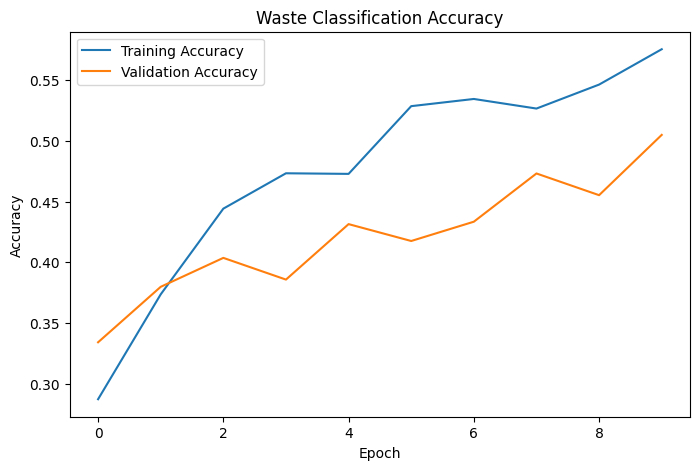

In [45]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Waste Classification Accuracy")

plt.legend()
plt.show()